In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset.csv")
print(df.head())

   amount location   device  is_fraud
0   20127   mumbai  android         0
1   13362   mumbai   iphone         0
2   20265  kolkata  android         0
3   33383  chennai      web         0
4   88130  chennai      web         0


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   amount    50000 non-null  int64
 1   location  50000 non-null  str  
 2   device    50000 non-null  str  
 3   is_fraud  50000 non-null  int64
dtypes: int64(2), str(2)
memory usage: 1.5 MB
None
            amount      is_fraud
count  50000.00000  50000.000000
mean   49847.60230      0.260600
std    28845.04994      0.438966
min       10.00000      0.000000
25%    24776.00000      0.000000
50%    49702.00000      0.000000
75%    74889.50000      1.000000
max    99997.00000      1.000000


amount      0
location    0
device      0
is_fraud    0
dtype: int64


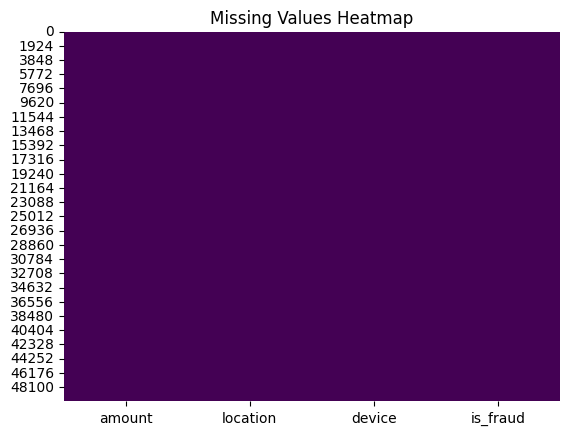

In [8]:
# -- Checking for missing values --
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

No missing values found in any of the columns


In [9]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [amount, location, device, is_fraud]
Index: []


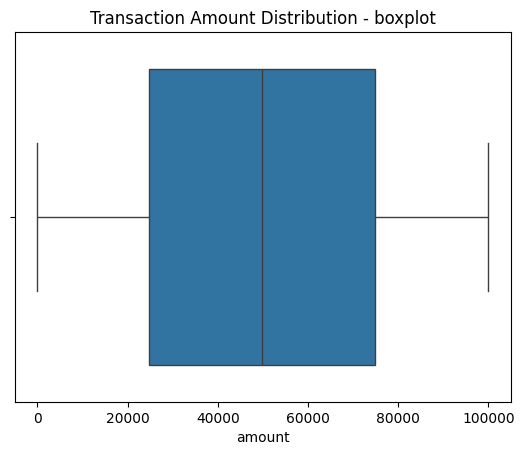

In [10]:
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount Distribution - boxplot")
plt.show()


Text(0.5, 0, 'Amount')

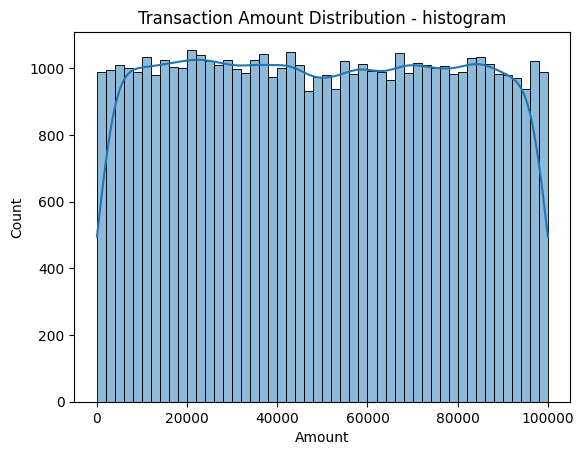

In [11]:
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution - histogram")
plt.xlabel("Amount")

In [12]:
# Check for imbalanced dataset

print(df['is_fraud'].value_counts())

is_fraud
0    36970
1    13030
Name: count, dtype: int64


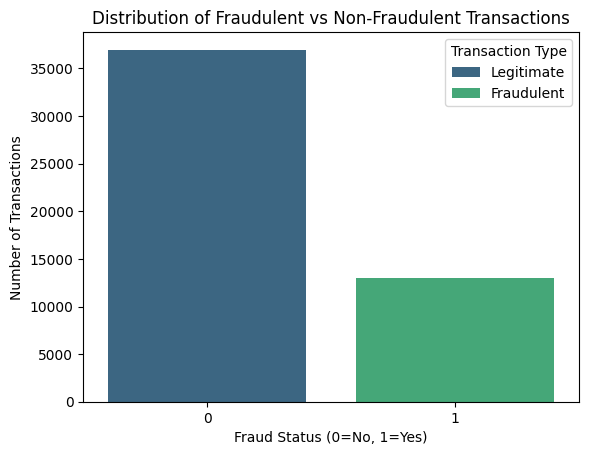

In [13]:
sns.countplot(x = 'is_fraud',
             data = df,
             palette = 'viridis',
             legend=True,
             hue='is_fraud'
             )
plt.legend(title = 'Transaction Type', labels = ['Legitimate', 'Fraudulent'])
plt.title("Distribution of Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel('Fraud Status (0=No, 1=Yes)')
plt.ylabel('Number of Transactions')

plt.show()


This is an imbalanced dataset